In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

print(df.head())

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


In [4]:
from statsmodels.tsa.arima.model import ARIMA

# Differencing (to remove trend)
df['diff'] = df['Passengers'].diff().dropna()
diff_series = df['Passengers'].diff().dropna()

# # MA(1)
# model = ARIMA(df['Passengers'], order=(0,1,1))
# model_fit = model.fit()

# print(model_fit.summary())

<Figure size 640x480 with 0 Axes>

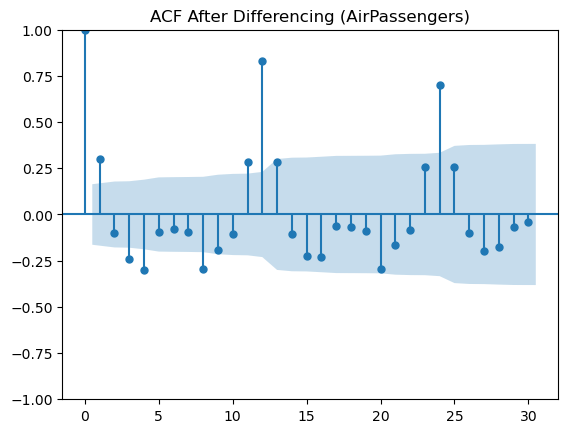

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
plt.figure()
plot_acf(diff_series, lags=30)
plt.title("ACF After Differencing (AirPassengers)")
plt.show()

In [6]:
# MA(1)
model = ARIMA(df['Passengers'], order=(0,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -696.629
Date:                Wed, 22 Apr 2026   AIC                           1397.258
Time:                        13:34:23   BIC                           1403.183
Sample:                    01-01-1949   HQIC                          1399.665
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.4027      0.077      5.252      0.000       0.252       0.553
sigma2       996.0870    108.453      9.184      0.000     783.522    1208.652
Ljung-Box (L1) (Q):                   0.07   Jarque-

C:\Users\PYTHON\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\PYTHON\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\PYTHON\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [7]:
forecast = model_fit.forecast(steps=5)
print(forecast)

1961-01-01    459.50383
1961-02-01    459.50383
1961-03-01    459.50383
1961-04-01    459.50383
1961-05-01    459.50383
Freq: MS, Name: predicted_mean, dtype: float64


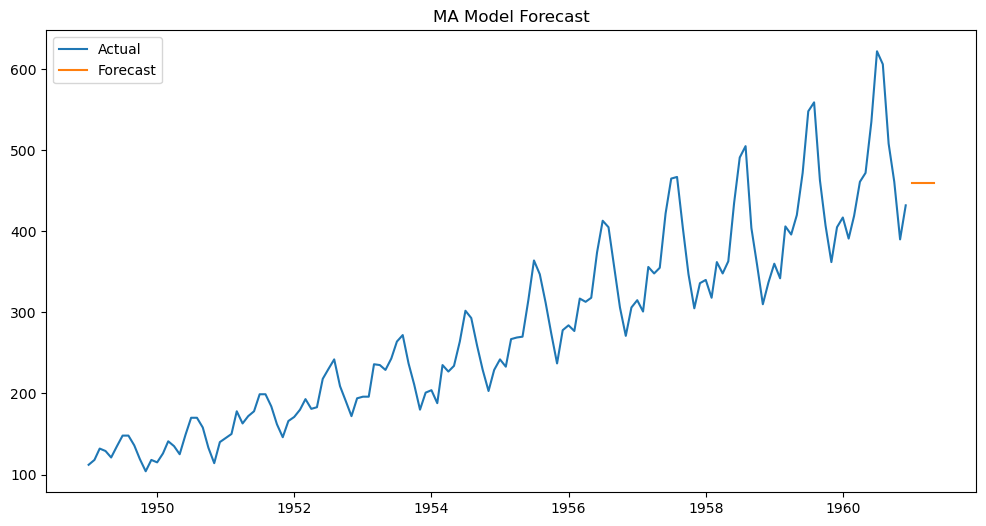

In [8]:
plt.figure(figsize=(12,6))
plt.plot(df['Passengers'], label="Actual")
plt.plot(forecast, label="Forecast")
plt.legend()
plt.title("MA Model Forecast")
plt.show()